In [1]:
!pip install gudhi --quiet
!pip install scikit-tda --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import gudhi as gd
import tadasets
import ripser
import persim
from persim import PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple

In [3]:
np.random.seed(4052003)

In [4]:
data = tadasets.torus(n = 1000, noise = 0)

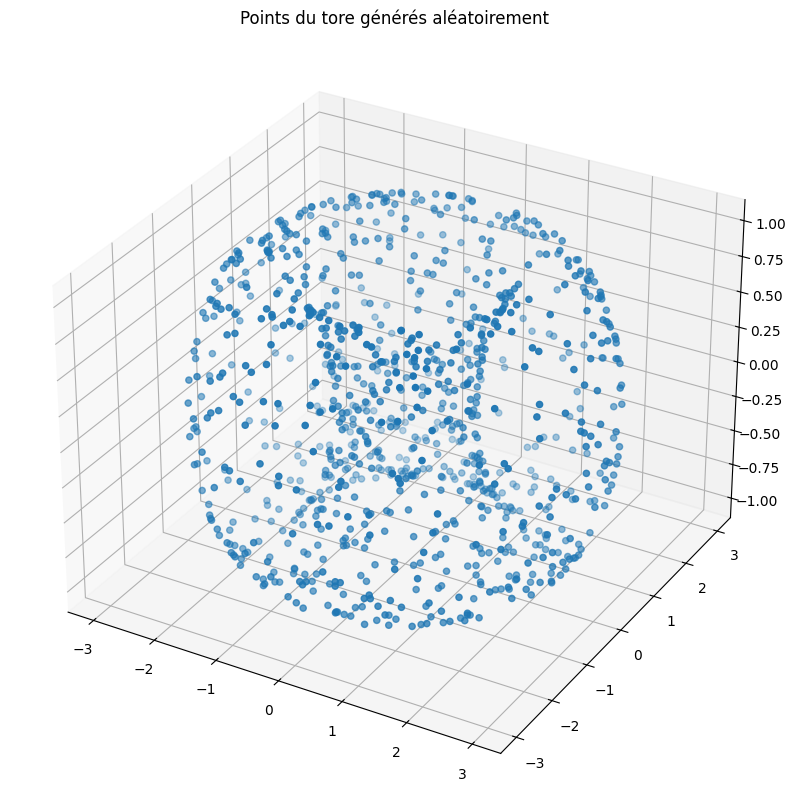

In [5]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement")
plt.savefig('tore.png')

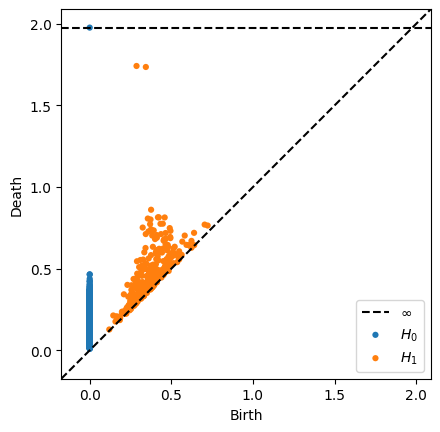

In [6]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=False
)
plt.savefig("diagram.png")

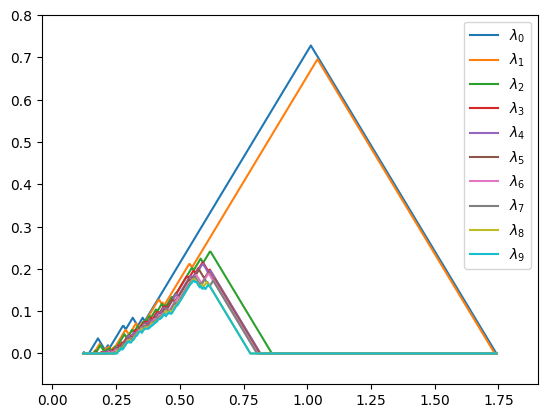

In [7]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))
plt.savefig("pl.png")

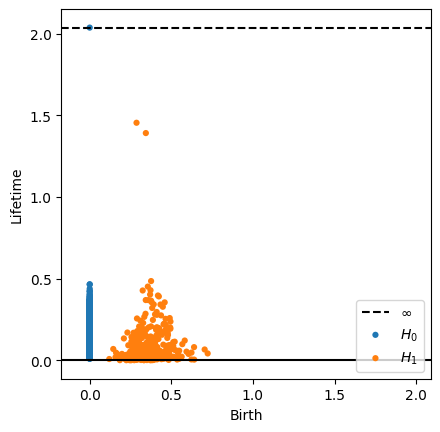

In [8]:
persim.plot_diagrams(
    dgm,
    lifetime=True,
    show=False
)
plt.savefig("persistance.png")

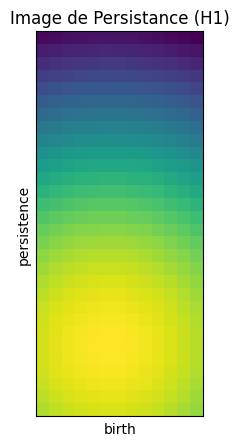

In [9]:
from persim import PersistenceImager

"""def weighting_logistic(birth, lifetime, k=10, x0=0.2):
    
    birth : tableau des naissances (envoyé automatiquement par persim)
    lifetime : tableau des persistances (death - birth) (envoyé automatiquement)
    k, x0 : vos paramètres personnalisés
    # On applique la sigmoïde directement sur la lifetime
    weights = 1 / (1 + np.exp(-k * (lifetime - x0)))
    return weights

mes_parametres = {'k': 10, 'x0': 0.1} # Ajustez x0 selon vos données !

pimager = PersistenceImager(
    pixel_size=0.07, 
    weight=weighting_logistic,      # Votre fonction
    weight_params=mes_parametres    # <--- INDISPENSABLE pour écraser le 'n' par défaut
)

fig2 = plt.figure(figsize = (6, 6))
ax = fig2.add_subplot(1, 1, 1)
pimager.plot_image(imgs[0], ax=ax)"""


from persim import PersistenceImager

# 1. On définit la fonction de poids CORRECTE (sans le 'n')
def weighting_logistic(birth, lifetime, k=10, x0=0.2):
    # Tout ce qui est en dessous de x0 sera écrasé vers 0
    return 1 / (1 + np.exp(-k * (lifetime - x0)))

# 2. On configure l'imageur
pimager = PersistenceImager(
    pixel_size=0.05,  # Un peu plus fin que 0.07
    weight=weighting_logistic, 
    weight_params={'k': 20, 'x0': 0.2} # <-- Augmentez x0 pour cacher le bruit
)

# 3. Sélection des données (H1 uniquement)
# dgm[1] est l'array des points H1. On le met dans une liste [ ... ] pour fit()
h1_diagram = [dgm[1]] 

pimager.fit(h1_diagram)
imgs = pimager.transform(h1_diagram)

# 4. Affichage
fig, ax = plt.subplots(figsize=(5,5))
pimager.plot_image(imgs[0], ax=ax)
plt.title("Image de Persistance (H1)")
plt.savefig("persim.png")


In [10]:
"""rips_complex = gd.RipsComplex(points=data, max_edge_length=5)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=3)
diag = simplex_tree.persistence(min_persistence=0.4)

gd.plot_persistence_barcode(diag)
plt.show()"""

'rips_complex = gd.RipsComplex(points=data, max_edge_length=5)\nsimplex_tree = rips_complex.create_simplex_tree(max_dimension=3)\ndiag = simplex_tree.persistence(min_persistence=0.4)\n\ngd.plot_persistence_barcode(diag)\nplt.show()'

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.05')

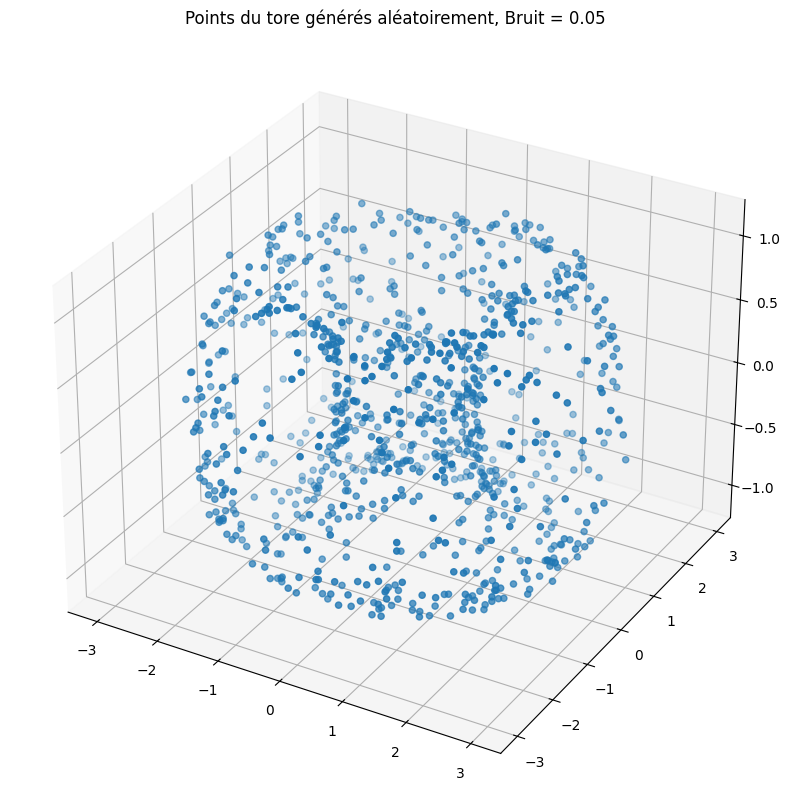

In [11]:
#Deuxième session 

data_05 = tadasets.torus(n = 1000, noise = 0.05)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data_05[:,0], data_05[:, 1], data_05[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.05")

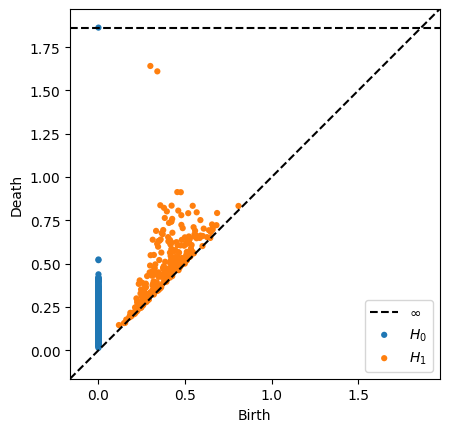

In [12]:
dgm = ripser.ripser(data_05, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

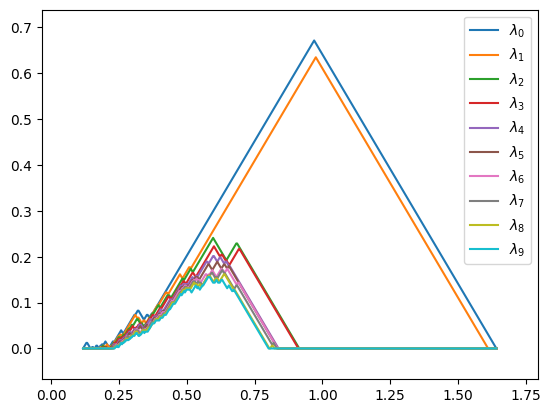

In [13]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.1')

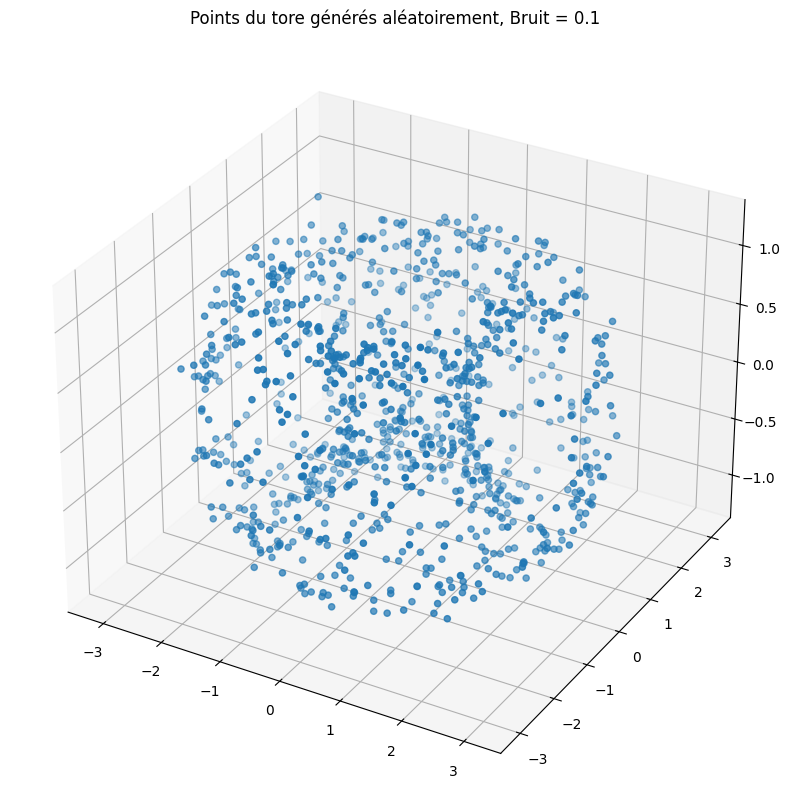

In [14]:
data = tadasets.torus(n = 1000, noise = 0.1)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.1")

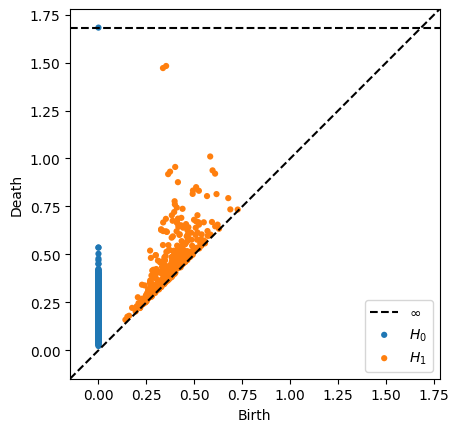

In [15]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

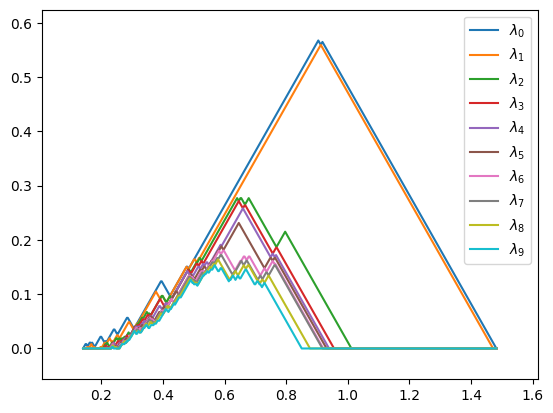

In [16]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

Text(0.5, 0.92, 'Points du tore générés aléatoirement, Bruit = 0.2')

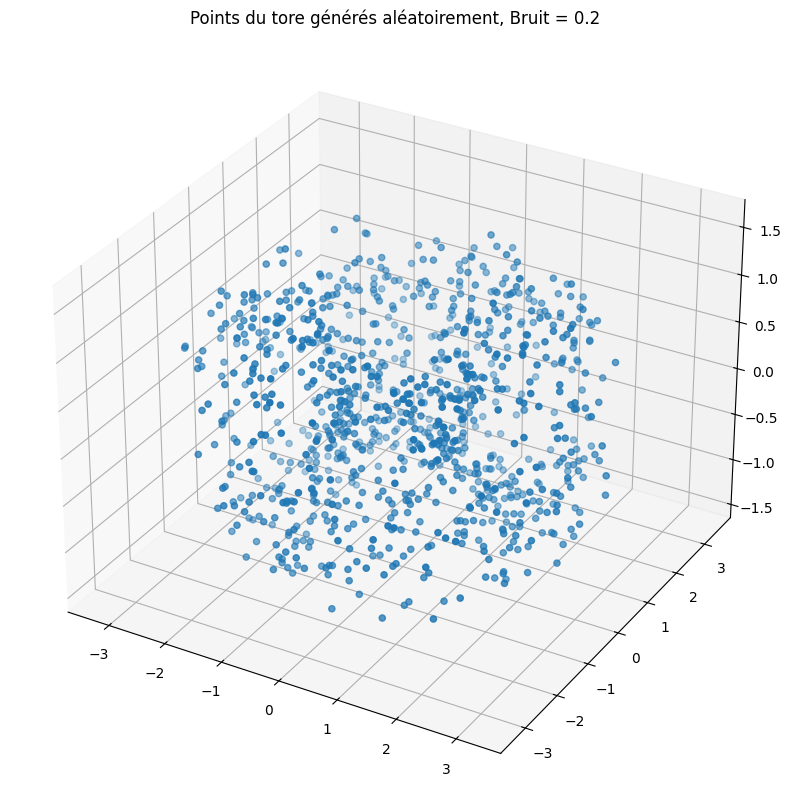

In [17]:
data = tadasets.torus(n = 1000, noise = 0.2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.scatter(data[:,0], data[:, 1], data[:,2])
ax.set_title("Points du tore générés aléatoirement, Bruit = 0.2")

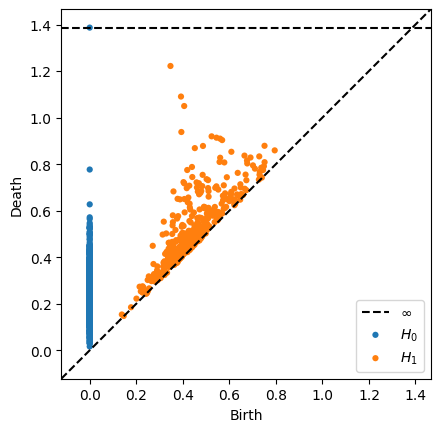

In [18]:
dgm = ripser.ripser(data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

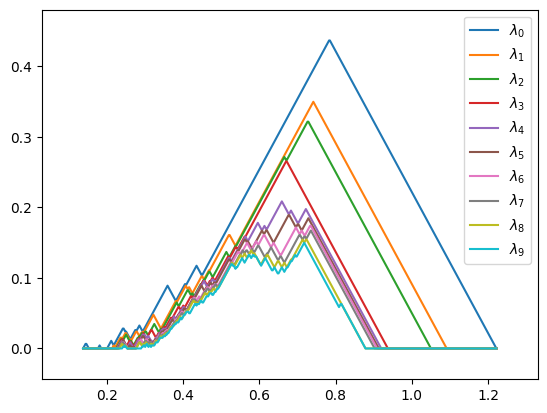

In [19]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

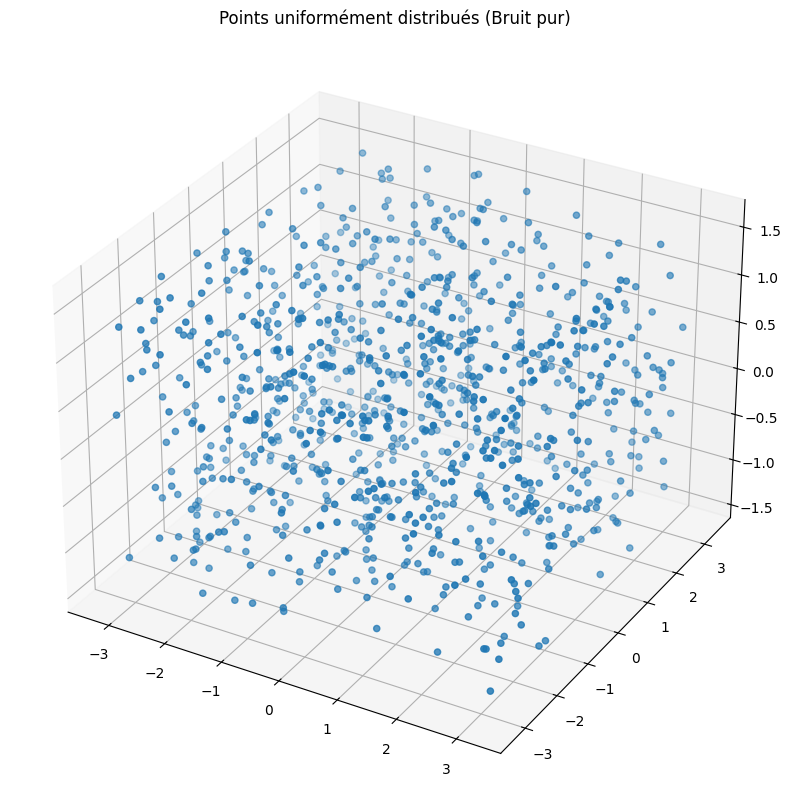

In [20]:
x_min, x_max = data[:, 0].min(), data[:, 0].max()
y_min, y_max = data[:, 1].min(), data[:, 1].max()
z_min, z_max = data[:, 2].min(), data[:, 2].max()


n_points = 1000  
uniform_data = np.random.uniform(
    low=[x_min, y_min, z_min],
    high=[x_max, y_max, z_max],
    size=(n_points, 3)
)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(uniform_data[:, 0], uniform_data[:, 1], uniform_data[:, 2])
ax.set_title("Points uniformément distribués (Bruit pur)")
plt.show()

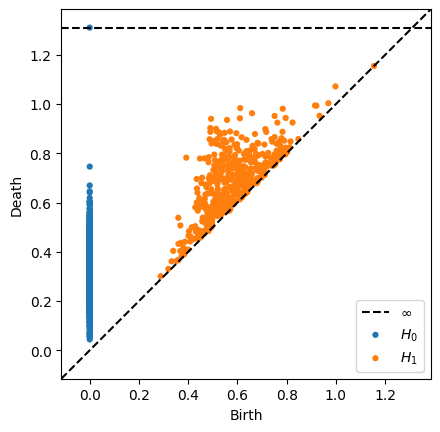

In [21]:
dgm = ripser.ripser(uniform_data, maxdim = 1)['dgms']
persim.plot_diagrams(
    dgm,
    show=True
)

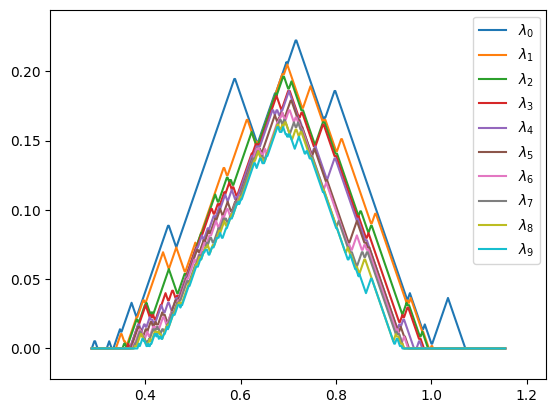

In [22]:
pla = PersLandscapeApprox(dgms=dgm,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range = range(10))

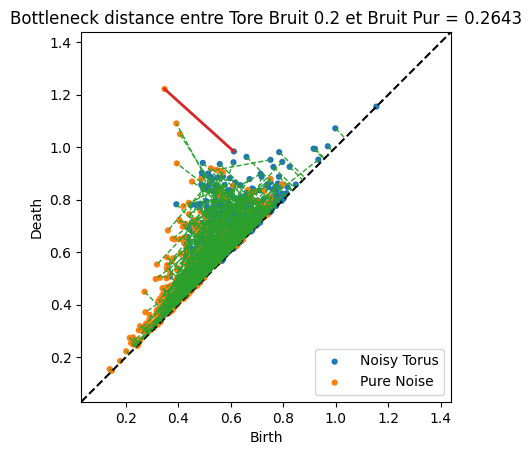

In [23]:
dgm_unif = ripser.ripser(uniform_data)['dgms'][1]
dgm_torus = ripser.ripser(data)['dgms'][1]

distance_bottleneck, matching = persim.bottleneck(dgm_unif, dgm_torus, matching=True)

persim.bottleneck_matching(
    dgm_unif, dgm_torus, matching,
    labels=['Noisy Torus', 'Pure Noise']
)
plt.title(f"Bottleneck distance entre Tore Bruit 0.2 et Bruit Pur = {distance_bottleneck:0.4f}")
plt.show()


In [24]:
distance_wasserstein = persim.wasserstein(dgm_unif, dgm_torus)

print(f"Distance de Wasserstein : {distance_wasserstein:.4f}")

Distance de Wasserstein : 26.5827


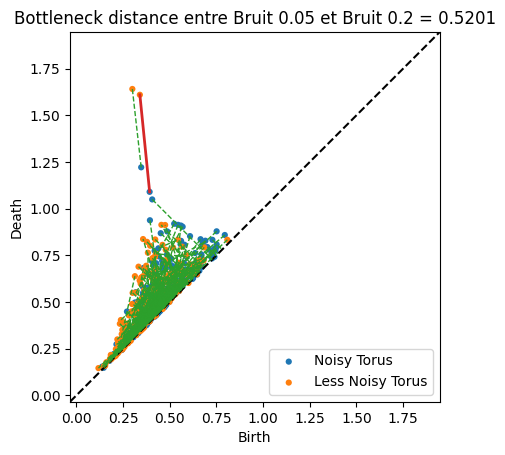

In [25]:


dgm_tore_plus_bruite = ripser.ripser(data)['dgms'][1]
dgm_tore_moins_bruite = ripser.ripser(data_05)['dgms'][1]

distance_bottleneck, matching = persim.bottleneck(dgm_tore_plus_bruite, dgm_tore_moins_bruite, matching=True)

persim.bottleneck_matching(
    dgm_tore_plus_bruite, dgm_tore_moins_bruite, matching,
    labels=['Noisy Torus', 'Less Noisy Torus']
)
plt.title(f"Bottleneck distance entre Bruit 0.05 et Bruit 0.2 = {distance_bottleneck:0.4f}",)
plt.show()

In [26]:
distance_wasserstein = persim.wasserstein(dgm_tore_plus_bruite, dgm_tore_moins_bruite)

print(f"Distance de Wasserstein : {distance_wasserstein:.4f}")

Distance de Wasserstein : 9.7494


On remarque que la distance bottleneck est plus grande entre le tore bruité à 0.05 et le tore bruité à 0.2 qu'entre le tore bruité à 0.2 et le bruit pur. Pour la distance de Wassertstein, c'est l'inverse. Comment interpréter cela ? La distance de Wasserstein paraît être meilleure pour trouver des structures topologiques. 

On va maintenant réfléchir à une autre manère de simuler le bruit. 

In [27]:
shuffled_data = np.copy(data)


for i in range(shuffled_data.shape[1]):
    np.random.shuffle(shuffled_data[:, i])


dgm_torus = ripser.ripser(data)['dgms'][1]
dgm_shuffled = ripser.ripser(shuffled_data)['dgms'][1]


dist_wash = persim.wasserstein(dgm_torus, dgm_shuffled)

print(f"Distance de Wasserstein (Tore vs Shuffled) : {dist_wash:.4f}")

Distance de Wasserstein (Tore vs Shuffled) : 13.2257


La distance est quand même plus élevée que dans le cas de deux tores. 

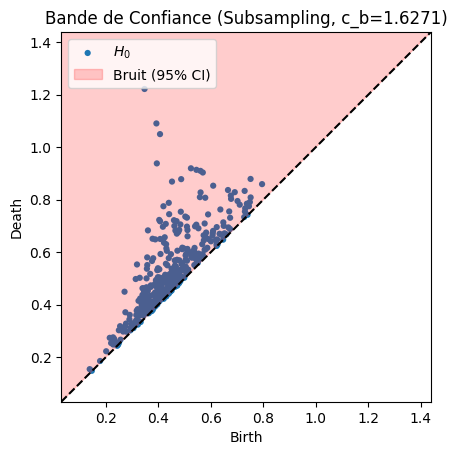

In [28]:
from scipy.spatial.distance import directed_hausdorff

# 2. Estimation de la valeur critique c_b (Méthode I : Subsampling)
n_points = len(data)
b = int(0.8 * n_points)  # Taille du sous-échantillon (80% conseillé)
N = 100                  # 100 répétitions suffisent pour une bonne estimation
T_j = []

for i in range(N):
    # Tirage d'un sous-échantillon aléatoire
    idx = np.random.choice(n_points, b, replace=False)
    subsample = data[idx]
    
    # Calcul de la distance de Hausdorff spatiale (très rapide)
    # H(A, B) = max( d_directed(A,B), d_directed(B,A) )
    d1 = directed_hausdorff(subsample, data)[0]
    d2 = directed_hausdorff(data, subsample)[0]
    T_j.append(max(d1, d2))

# Calcul de c_b d'après la formule de l'article : c_b = 2 * Quantile(95%)
# Source : Fasy et al., Page 11, Équation 13 et Théorème 3
q = np.percentile(T_j, 95)
c_b = 2 * q

# 3. Affichage du diagramme avec la bande de confiance
persim.plot_diagrams(dgm_torus, show=False)
ax = plt.gca()

# La limite de "Signal" est située à 2 * c_b de persistance
# Source : Fasy et al., Page 10, Paragraphe 4 : "band of width sqrt(2)*c_n"
# Cela correspond à une persistance (Death - Birth) > 2 * c_b
band_limit = 2 * c_b
x_range = np.linspace(0, ax.get_xlim()[1], 100)
ax.fill_between(x_range, x_range, x_range + band_limit, color='red', alpha=0.2, label='Bruit (95% CI)')

plt.title(f"Bande de Confiance (Subsampling, c_b={c_b:.4f})")
plt.legend()
plt.show()
